In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("youtube_dataset.csv.csv")
df.head()


,video_id,title,channel_title,category,category_id,publish_date,publish_time,country,tags,views,likes,dislikes,comment_count,trending_date
0,vid_0,New Reaction 2024,SET India,Gaming,20,2023-11-19,23:48:56,US,tech|live|viral|trend|india,388180157,26415683,1281890,4853811,2023-11-24
1,vid_1,Official Song 2024,CarryMinati,News,25,2023-04-02,06:46:49,UK,video|viral|tech|sports|movie|india,215391128,11806628,927137,1275557,2023-04-03
2,vid_2,Top Review 2024,Aaj Tak,News,25,2024-10-25,00:36:04,US,video|funny|sports|viral|song|movie,222140488,11030931,830750,4065988,2024-10-29
3,vid_3,Emotional Song Hindi,News18 India,Lifestyle,26,2024-06-05,18:27:04,IN,sports|live|trend|video,57213696,4294239,108467,497494,2024-06-07
4,vid_4,Best Vlog USA,StarPlus,Music,10,2024-01-23,02:30:07,CA,funny|song|india|sports|movie|tech|video,202124398,14308235,852222,307400,2024-01-24


2. Basic Info

In [2]:

df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   video_id       20000 non-null  object
 1   title          20000 non-null  object
 2   channel_title  20000 non-null  object
 3   category       20000 non-null  object
 4   category_id    20000 non-null  int64 
 5   publish_date   20000 non-null  object
 6   publish_time   20000 non-null  object
 7   country        20000 non-null  object
 8   tags           20000 non-null  object
 9   views          20000 non-null  int64 
 10  likes          20000 non-null  int64 
 11  dislikes       20000 non-null  int64 
 12  comment_count  20000 non-null  int64 
 13  trending_date  20000 non-null  object
dtypes: int64(5), object(9)
memory usage: 1.4+ MB


video_id         0
title            0
channel_title    0
category         0
category_id      0
publish_date     0
publish_time     0
country          0
tags             0
views            0
likes            0
dislikes         0
comment_count    0
trending_date    0
dtype: int64

3. Clean Date Columns

In [3]:

df["publish_date"] = pd.to_datetime(df["publish_date"])
df["trending_date"] = pd.to_datetime(df["trending_date"])

4. Combine publish_date + publish_time → publish_datetime

In [4]:

df["publish_datetime"] = pd.to_datetime(
    df["publish_date"].astype(str) + " " + df["publish_time"]
)

5. Create Time Features

In [5]:

df["publish_year"] = df["publish_datetime"].dt.year
df["publish_month"] = df["publish_datetime"].dt.month
df["publish_day"] = df["publish_datetime"].dt.day
df["publish_hour"] = df["publish_datetime"].dt.hour
df["publish_day_name"] = df["publish_datetime"].dt.day_name()

6. Trending Features

In [6]:

df["trending_year"] = df["trending_date"].dt.year
df["trending_month"] = df["trending_date"].dt.month
df["trending_day"] = df["trending_date"].dt.day

7. Trend Duration

In [7]:

df["trend_duration_days"] = (df["trending_date"] - df["publish_date"]).dt.days

8. Save cleaned file

In [8]:

df.to_csv("youtube_clean_final.csv", index=False)

— PYTHON VISUALIZATIONS (MATPLOTLIB)

1. Top 10 Channels by Views

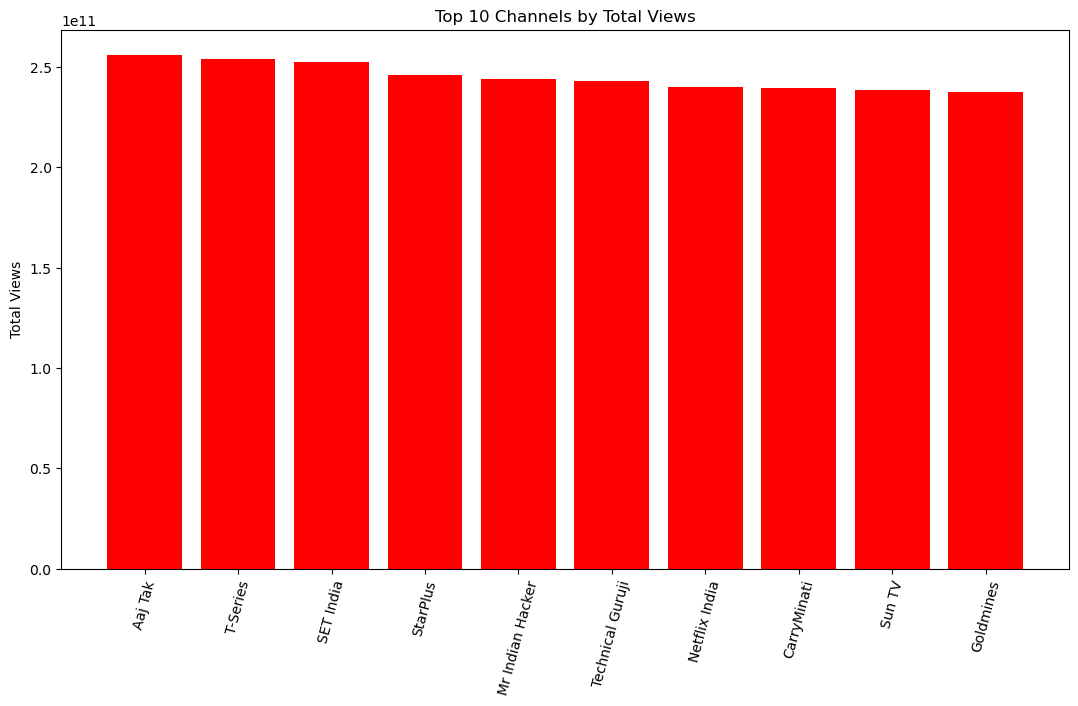

In [10]:

top_channels = df.groupby("channel_title")["views"].sum().nlargest(10)

plt.figure(figsize=(13,7))
plt.bar(top_channels.index, top_channels.values, color="red")
plt.xticks(rotation=75)
plt.title("Top 10 Channels by Total Views")
plt.ylabel("Total Views")
plt.show()

2. Category-wise Views

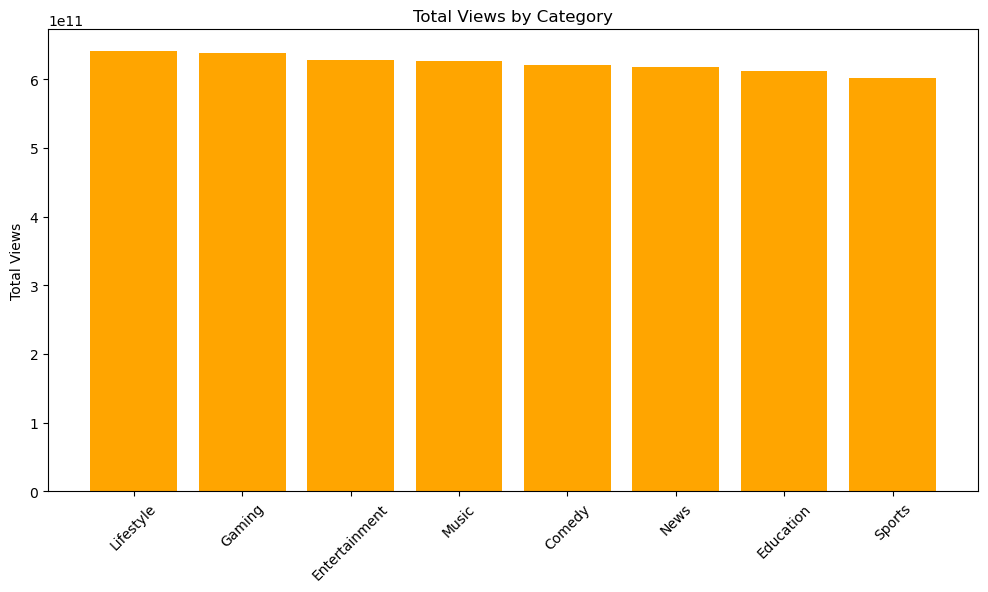

In [11]:

category_views = df.groupby("category")["views"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
plt.bar(category_views.index, category_views.values, color="orange")
plt.xticks(rotation=45)
plt.title("Total Views by Category")
plt.ylabel("Total Views")
plt.show()

3. Monthly Trends

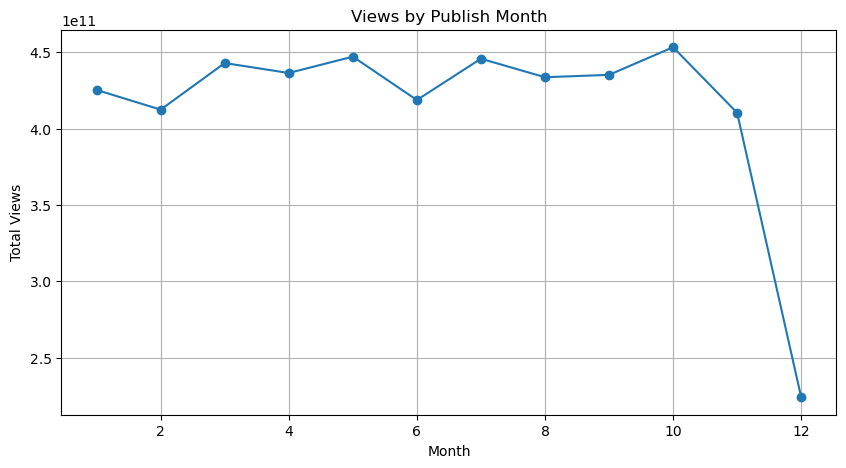

In [12]:

monthly = df.groupby("publish_month")["views"].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly.index, monthly.values, marker="o")
plt.title("Views by Publish Month")
plt.xlabel("Month")
plt.ylabel("Total Views")
plt.grid()
plt.show()

4. Trend Duration Distribution

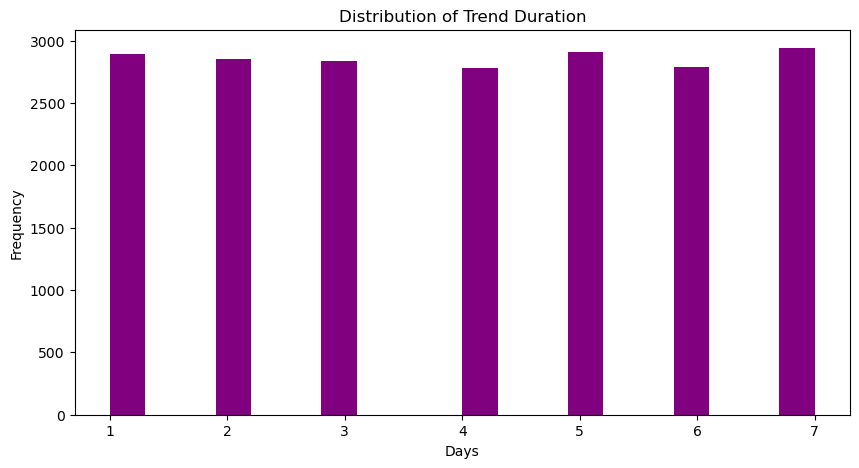

In [13]:

plt.figure(figsize=(10,5))
plt.hist(df["trend_duration_days"], bins=20, color="purple")
plt.title("Distribution of Trend Duration")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()

5. Views vs Likes Scatter Plot

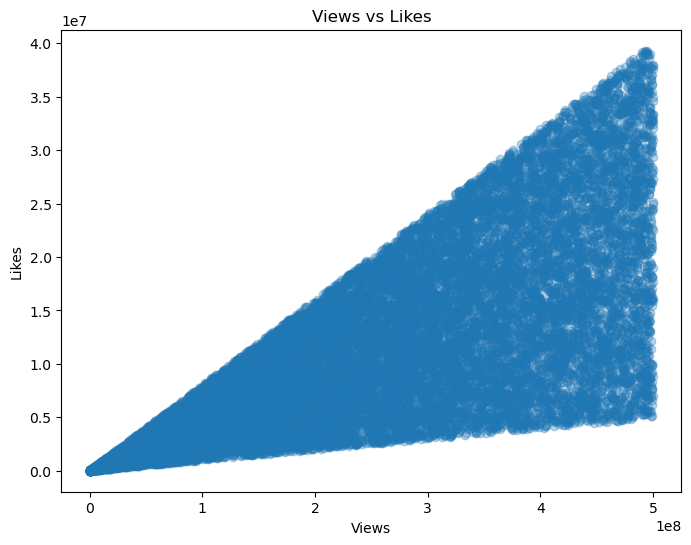

In [14]:

plt.figure(figsize=(8,6))
plt.scatter(df["views"], df["likes"], alpha=0.3)
plt.title("Views vs Likes")
plt.xlabel("Views")
plt.ylabel("Likes")
plt.show()

6 — Views by Country

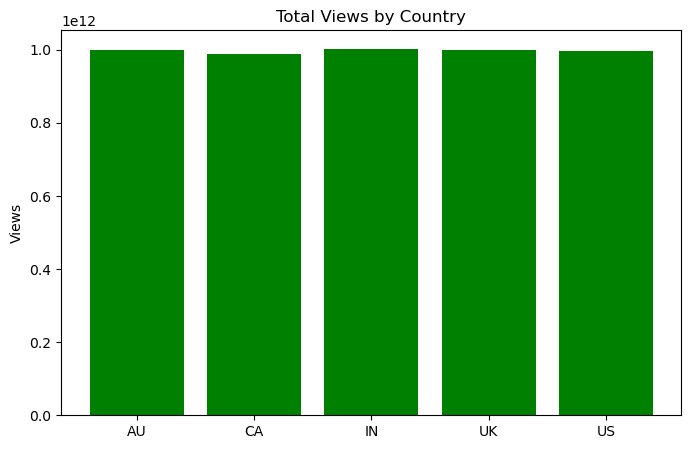

In [15]:

country_views = df.groupby("country")["views"].sum()

plt.figure(figsize=(8,5))
plt.bar(country_views.index, country_views.values, color="green")
plt.title("Total Views by Country")
plt.ylabel("Views")
plt.show()

7 — Top 10 Videos by Views

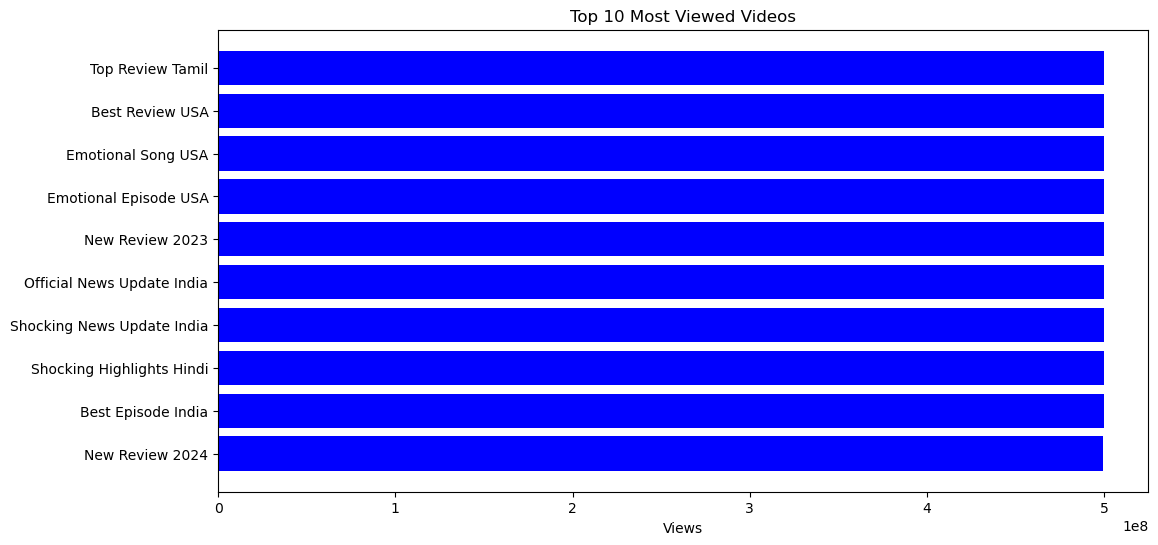

In [16]:

top_videos = df.nlargest(10, "views")[["title", "views"]]

plt.figure(figsize=(12,6))
plt.barh(top_videos["title"], top_videos["views"], color="blue")
plt.title("Top 10 Most Viewed Videos")
plt.xlabel("Views")
plt.gca().invert_yaxis()
plt.show()

8 — Best Publish Hour for Views

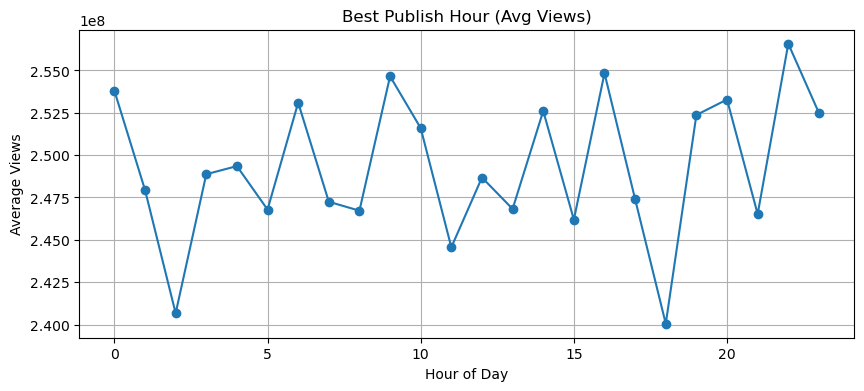

In [17]:

hour_views = df.groupby("publish_hour")["views"].mean()

plt.figure(figsize=(10,4))
plt.plot(hour_views.index, hour_views.values, marker="o")
plt.title("Best Publish Hour (Avg Views)")
plt.xlabel("Hour of Day")
plt.ylabel("Average Views")
plt.grid()
plt.show()

9 — Category-wise Average Likes

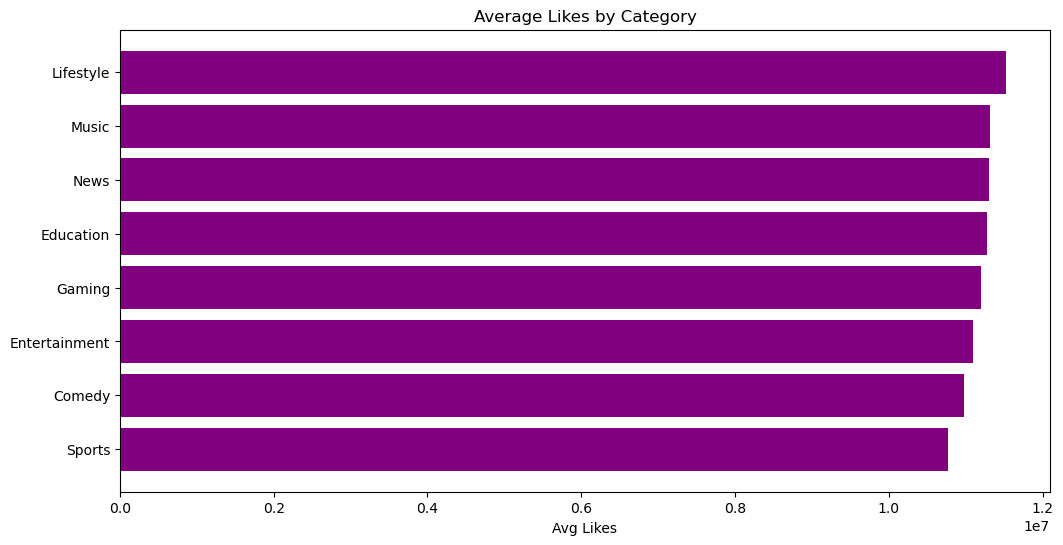

In [18]:

cat_likes = df.groupby("category")["likes"].mean().sort_values()

plt.figure(figsize=(12,6))
plt.barh(cat_likes.index, cat_likes.values, color="purple")
plt.title("Average Likes by Category")
plt.xlabel("Avg Likes")
plt.show()